# **Project 1 - Sales Analysis - Visualisations

## Objectives

- Read data from combined csv files created from ETL processes
- Show plots to attempt to answer hypothesis


## Inputs

CSV files used:

Sales_Combined_DataSet.csv


Note: original files are stored in Data/OriginalFiles


## Outputs

CSV file created from ETL etc stored in Data:

Sales_Combined.csv



## Additional Comments

- Using as many of the plot libraries as possible but discovered some where not capable of showing the data in either the format I needed.

Needed to install:

pip install nbformat

For plotly visualisations to work


- Isolated the visualisations into a seperate notebook to keep the file size as low as possible.


## Initalise Working Environment

In [39]:
#import libraries
import os
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

#added by me for visualisation fine tuning
from matplotlib.ticker import MultipleLocator

#added by me for plotly.express visualisation issue
import nbformat 


# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 

In [40]:
#DataFrame vars for visualisation
dfSales_Combined_DataSet = None
#just in case need to add more Feature Engineering
dfSales_Combined_DataSet_Work = None

#stores current directory
strCurrentDir = ""

#constant for project directory
CNST_STR_PROJECT_DIR = "Project1-SalesAnalysis"

#file path constant
CNST_STR_SALESCOMBINEDFILEPATH = "/Data/VisualisationDataSet/Sales_Combined_DataSet.csv"

#other vars
lstStoreRanges = []
lstLabels = []
objStore = None


## Set Current Directory To Base Project Directory

In [41]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/rogerwilliams/Projects/Python/CourseProjects/Project1-SalesAnalysis


# Section 1 - Read Data From CSV File

- Read csv file

## Read csv File Into Variable For Processing

In [42]:
#read csv files into DataFrames
dfSales_Combined_DataSet = pd.read_csv(strCurrentDir + CNST_STR_SALESCOMBINEDFILEPATH)


---

## Visualisations!

Each hypothesis will be visualised using:

- pandas
- matplotlib.pyplot
- plotly.express
- seaborn


## Hypothesis 1

Are sales increased if weather is hotter or colder? 

## Visualisation library: pandas

In [ ]:
#pandas visualisation for hypothesis 1 - Sales vs Temperature
dfSales_Combined_DataSet.plot(kind="scatter", x="Temperature", y="Weekly_Sales", 
                              title="Sales vs Temperature", color="green", alpha=0.5)


## Observations

Looks decent, certainly answers the hypothesis

## Visualisation library: matplotlib.pyplot

In [ ]:
#matplotlib visualisation for hypothesis 1 - Sales vs Temperature

#used chatGPT code to get "ticks" between axis values
#however due to a lack of knowledge am running the plot first then deciding what the
#ticks values are -DOH!

#Is there a correlation between temperature and sales? 
fig, ax = plt.subplots(figsize=(12, 20))

ax.scatter(
    dfSales_Combined_DataSet["Temperature"],
    dfSales_Combined_DataSet["Weekly_Sales"],
    alpha=1,
    label="Temperature",
    color="green",
    s=10
)


#this code came from chatGPT and has been HEAVILY modified
# Major ticks every 20 units
ax.xaxis.set_major_locator(MultipleLocator(20))

# Minor ticks every 2 units
ax.xaxis.set_minor_locator(MultipleLocator(2))

#my added code
# Major ticks every 100000 units
ax.yaxis.set_major_locator(MultipleLocator(20000))

# Minor ticks every 2000 units
ax.yaxis.set_minor_locator(MultipleLocator(2000))

ax.tick_params(axis='y', which='minor', length=4, width=1.2)
ax.tick_params(axis='y', which='major', length=8, width=0.8)
#end of my added code


# Make minor tick marks visible
ax.tick_params(axis='x', which='minor', length=4, width=1.2)
ax.tick_params(axis='x', which='major', length=8, width=0.8)
#end of chatGPT code

#set title and labels
ax.set_title("Scatter Plot Of Temperature Vs Weekly Sales")
ax.set_xlabel("Temperature (Farenheit)")
ax.set_ylabel("Weekly Sales")
#position legend
ax.legend(loc="upper right")
#show plot!
plt.show()



## Observations

Due to the added "ticks" between each axis value needd to make the plot bigger to see the data points, but the plot looks good and answers the hypothesis.

Note: Is there a better way of doing this?

## Visualisation library: plotly.express

In [ ]:
#plotly visualisation for hypothesis 1 - Sales vs Temperature
#Note: in order for the "ticks" to show on the axes Plotly needs to be version 5.8 or higher

fig = px.scatter(dfSales_Combined_DataSet, x="Temperature", y="Weekly_Sales",
           title="Sales vs Temperature", color="Temperature", opacity=0.5)

#code copied from chatGPT
fig.update_xaxes(
    ticks="outside",
    minor=dict(
        ticks="outside",
        ticklen=4,
        showgrid=False
    )
)

fig.update_yaxes(
    ticks="outside",
    minor=dict(
        ticks="outside",
        ticklen=4,
        showgrid=False
    )
)
#remove after testing
#fig.update_xaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
#fig.update_yaxes(showgrid=True, gridcolor="lightgray", gridwidth=1)
fig.update_xaxes(dtick=10)        # every 10 degrees
fig.update_yaxes(dtick=100000)    # every 100,000 sales
#end code copied from chatGPT

fig.show()

## Observations

Answers the hypothesis and is the best looking plot so far intially.  
However, seems to be missing some higher values (??) - need to investigate further.

## Visualisation library: SeaBorn

In [ ]:
#seaborn visualisation for hypothesis 1 - Sales vs Temperature
fig =sns.scatterplot(data=dfSales_Combined_DataSet, x="Temperature", y="Weekly_Sales", 
                color="green", alpha=0.5)

fig.set_title("Scatter Plot Of Temperature Vs Weekly Sales")

## Observations

Answers hypothesis not as good looking as the plotly version

## Visualisation library: Plotly

In [ ]:
#plotly visualisation for hypothesis 1 - Sales vs Temperature

#used chatGPT code to get "ticks" between axis values
#however due to a lack of knowldege am running the plot first then deciding what the
#ticks values are -DOH!

#Is there a correlation between temperature and sales? 
fig = px.scatter(
    dfSales_Combined_DataSet,
    x="Temperature",
    y="Weekly_Sales"
)

#set title and labels
fig.update_layout(
    title="Scatter Plot Of Temperature Vs Weekly Sales",
    xaxis_title="Temperature (Farenheit)",
    yaxis_title="Weekly Sales"
)
#show plot!
fig.show()



## Observations

Answers the hypothesis.
However, seems to be missing some higher values (??) - need to investigate further.

## Conclusions - Hypothesis 1

When I looked at the raw data files this hypothesis came to mind, but as always when new to something knowing WHICH plot to use and IF the hypothesis is even feasible were the main issues.

Thought scatter plot best represents the data.

Fingers crossed I have chose wisely, as to me it shows what was required

## Hypothesis 2

Sales differences between holiday and non-holiday weeks per store

## Visualisation library: pandas

After many attempts discovered pandas on its own could not visualise the data the way I envisaged, and what it produced was hard to read and understand.
So have used matplotlib.pyplot to visualise the data instead so nothing more in this section

## Visualisation library: pandas/matplotlib.pyplot

In [ ]:
#pandas/matplotlib.pyplot visualisation for hypothesis 2 - Sales differences between holiday and non-holiday weeks per store


#define list of store numbers as a set of ranges
#there is probably some clever way of doing this dynamically but I don't know it!
#so went "old skool" and simply looked at the last store number in the csv file: stores data-set.csv
#obviously if more stores are added this isn't a good solution!
lstStoreRanges = [
    range(1, 10),
    range(10, 20),
    range(20, 30),
    range(30, 40),
    range(40, 46)
]

#read through DataFrame see if store number is in range
#Note: this is probably a mute step but is a a god way of validating the result BEFORE
#      creating a plot

for intStores in lstStoreRanges:
    #add row to new DataFrame
    dfSales_Combined_DataSet_SubSet = dfSales_Combined_DataSet[
        dfSales_Combined_DataSet["Store"].isin(intStores)
    ]

    #set subplots defaults
    ax = dfSales_Combined_DataSet_SubSet.boxplot(
        column="Weekly_Sales",
        by=["Store", "IsHoliday"],
        figsize=(20, 6),
        #rotate to make easier to read
        rot=90,
        color = "blue"
    )

    #avoid any unwanted titles
    plt.suptitle("")
    #set plot main title
    plt.title(f"Sales Differences Between Holiday and Non Holiday Weeks For Stores: {min(intStores)}-{max(intStores)}")
    #set axis
    plt.xlabel("Store / Holiday Status")
    plt.ylabel("Weekly Sales")

    #clear labels list
    lstLabels = []
    
    #if current store number matches the store number in the main loop
    for intCurrentStore in intStores:
        #make sure value actually exists
        if intCurrentStore in dfSales_Combined_DataSet_SubSet["Store"].unique():
           #update labels with meaningful data 
           lstLabels.append(f"Store {intCurrentStore}\nNon-Holiday")
           lstLabels.append(f"Store {intCurrentStore}\nHoliday")

    #update plot with new labels
    ax.set_xticklabels(lstLabels)

    #plt.tight_layout()
    plt.show()

## Observations

Answers the hypothesis, still looking for a better plot to visualise the data, main issue is the sheer volumne of it in terms of store numbers.

## Visualisation library: Plotly

In [ ]:
#plotly visualisation for hypothesis 2 - Sales differences between holiday and non-holiday weeks per store

#create plot
fig = px.box(dfSales_Combined_DataSet,
    x="Store",
    y="Weekly_Sales",
    color="IsHoliday",
    title="Sales Differences Between Holiday and Non-Holiday Weeks Per Store",
    labels={
        "IsHoliday": "Holiday Status",
        "Weekly_Sales": "Total Weekly Sales"
    },
    #set plot size
    height=600,
    width=1050
)

fig.show()

## Observations

Answers the hypothesis, best looking plot so far!

## Visualisation library: SeaBorn

In [ ]:
#seaborn visualisation for hypothesis 2 - Sales differences between holiday and non-holiday weeks per store

#set size of plot
plt.figure(figsize=(28, 12))
#set plot type, DataFrame, x/y axis columns and hue for holiday status
sns.boxplot(data=dfSales_Combined_DataSet, x="Store", y="Weekly_Sales", hue="IsHoliday", 
            width=0.8)
#set plot title
plt.title("Sales Differences Between Holiday and Non-Holiday Weeks Per Store")
#set axis labels
plt.xlabel("Store")
plt.ylabel("Total Weekly Sales")
#show plot
plt.show()



## Observations

Answers the hypothesis, not happy with the plot size compared to plotly, which so far is far superior in terms of look and readability..

Will see on the internet what the options for the plot type are...

## Conclusions - Hypothesis 2

Great idea, looks great in plotly, not so good in the others. 

As will all visualisations I am using, not aiming for the graphically stunning plot with zooming widgets and dancing bears. Aiming to present the information as clearly and simply as possible.

Thought boxplot was best after trying lots of options some of which would not render!

(Yes, I am secretly plotting (pun intended) to find a use for a 3D plot!!)

## Hypothesis 3

What is most profitable store type?

## Visualisation library: pandas/matplotlib.pyplot

In [ ]:
#pandas/matplotlib.pyplot visualisation for hypothesis 3: what is most profitable store type
#a question that has pondered the minds of great retail philosophers, can I answer it?

#filter data by doing simple grouby on store type and weekly sales
#reset the index so that the store type is a column and not an index
dfSales_Combined_DataSet_StoreType = dfSales_Combined_DataSet.groupby("Store_Type")["Weekly_Sales"].sum().reset_index()

#create the plot
ax = dfSales_Combined_DataSet_StoreType.plot(
    kind="bar",
    x="Store_Type",
    y="Weekly_Sales",
    title="Most Profitable Store By Type",
    legend=False,
    xlabel="Store Type",
    ylabel="Total Weekly Sales",
    #make sure x axis labels are not rotated
    rot=0
)

plt.show()

## Observations

Answers the hypothesis, just what I was looking for, clean, simple, direct.

Only issue is the mysterious: 1e9 in the top left corner(??)

## Visualisation library: Plotly

In [ ]:
#plotly visualisation for hypothesis 3 - What is most profitable store type?

#filter data by doing simple grouby on store type and weekly sales
#reset the index so that the store type is a column and not an index
dfSales_Combined_DataSet_StoreType = dfSales_Combined_DataSet.groupby("Store_Type")["Weekly_Sales"].sum().reset_index()

#create plot
fig = px.bar(dfSales_Combined_DataSet_StoreType,
    x="Store_Type",
    y="Weekly_Sales",
    color="Weekly_Sales",
    title="Most Profitable Store By Type",
    labels={
        "IsHoliday": "Holiday Status",
        "Weekly_Sales": "Total Weekly Sales"
    },
    #set plot size
    height=600,
    width=1050
)

#by default plotly will show 1B, 2B in the y axis so change it to something more understandable
fig.update_yaxes(
    tickprefix="£",
    tickformat=","
)
fig.show()

## Observations

Answers the hypothesis, just what I was looking for, clean, simple, direct as usual plotly rules!

## Visualisation library: SeaBorn

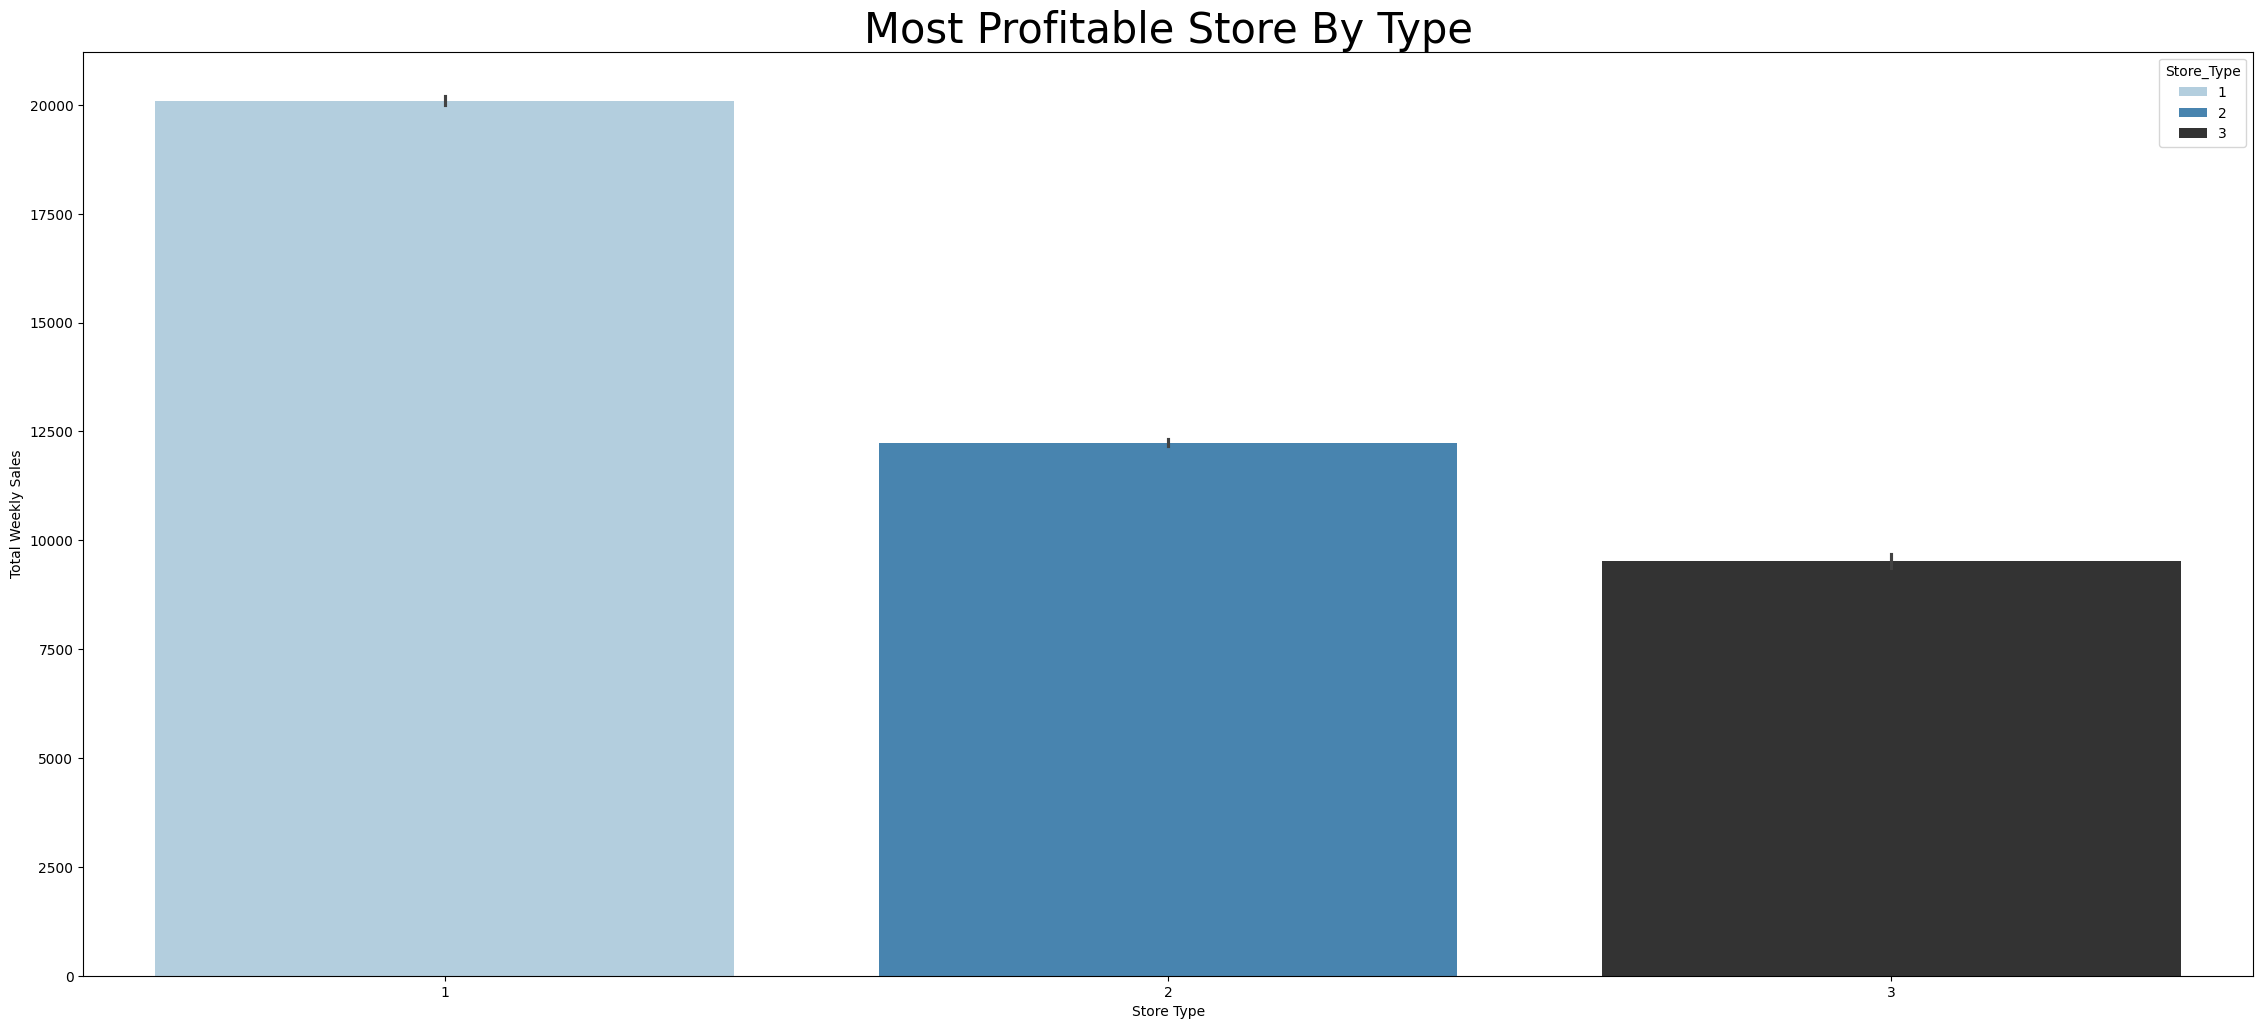

In [121]:
#seaborn visualisation for hypothesis 3 What is most profitable store type?

#set size of plot
plt.figure(figsize=(28, 12))
#set plot type, DataFrame, x/y axis columns and hue for holiday status
sns.barplot(data=dfSales_Combined_DataSet, x="Store_Type", y="Weekly_Sales",
            width=0.8, palette="Blues_d", hue="Store_Type")
#set plot title
plt.title("Most Profitable Store By Type",fontsize=30)
#set axis labels
plt.xlabel("Store Type")
plt.ylabel("Total Weekly Sales")
#show plot
plt.show()


## Observations

Answers the hypothesis, nice and simple, challenges the plotly version. Would prefer a gap between the title and the plot area. 

Will have snoop on the intenet if I have time..

## Conclusions - Hypothesis 3

Great idea, looks great in plotly, not so good in the others. 


## Hypothesis 4

Does store size affect profitability? If so, how much?

In [ ]:
#What is most profitable store type?

## Global Conclusions

Not completely happy with the visualisation, lack of knowledge/experience about best types of plots to use and best ways to process large datasets I think did impede me a little.

Practice makes perfect, and with what I have learnt so far I can only progress and me condifdent in my choices.


